In [1]:
import os

os.environ["CUDA_VISIBLE_DEVICES"] = "2"
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"

from tqdm.auto import tqdm
import numpy as np
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
from jax import grad, vmap, random
import optax
from seaborn import kdeplot
import wandb
from ot.lp import wasserstein_1d
import argparse
import pickle

from triangular_transport.flows.flow_trainer import (
    NNTrainer,
)

from triangular_transport.flows.interpolants import (
    linear_interpolant,
    linear_interpolant_der,
    trig_interpolant,
    trig_interpolant_der,
    sigmoid_interpolant,
    sigmoid_interpolant_der,
)
from triangular_transport.flows.loss_functions import vec_field_loss
from triangular_transport.networks.flow_networks import MLP
from triangular_transport.flows.methods.sampling import inf_train_gen
from triangular_transport.flows.dataloaders import (
    standard_gaussian_reference_sampler,
)

from triangular_transport.kernels.kernel_tools import (
    get_gaussianRBF,
    vectorize_kfunc,
    get_sum_of_kernels,
)
from ksd import compute_ksd_jax

/home/verano13/miniconda3/envs/stochastic-interpolants/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
nsamples = 20000
seed = 1
rng = np.random.RandomState(seed)
rej_samps = np.load("rej_samples_4.npy")
samps = rej_samps[rng.choice(100000, size=(nsamples, ))]
us_base = rng.randn(nsamples, 1)
base_wd = wasserstein_1d(
    us_base,
    samps,
    p=2
)
RANK = 5
cond_no = -4.2
sample_no = 1024
epochs = 7000
rng2 = np.random.RandomState(RANK)
x1_data = inf_train_gen(data="banana", rng=rng2, batch_size=100000)
target_data = x1_data[:sample_no, :]

key = random.PRNGKey(3 + 1 + RANK)
key, key1, key2, key3, key4 = random.split(key, 5)
key, subkey1 = random.split(key, 2)
train_dim = sample_no
batch_size = 2048
batch_size = min(batch_size, train_dim)
batch_size -= 1
steps_per_epoch = int(np.ceil(train_dim / batch_size))
steps = steps_per_epoch * epochs
print_every = 10000
yu_dimension = (1, 1)
dim = yu_dimension[0] + yu_dimension[1]
hidden_layer_list = [512] * 6
# hidden_layer_list = [256] * 3

In [61]:
model = MLP(
    key=key1,
    dim=dim,
    time_varying=True,
    w=hidden_layer_list,
    num_layers=len(hidden_layer_list) + 1,
    activation_fn=jax.nn.gelu,  # GeLU worked well
)
schedule = optax.warmup_cosine_decay_schedule(
    init_value=0.0,
    peak_value=1e-3,
    warmup_steps=2000,
    decay_steps=steps,
    end_value=1e-5,
)

optimizer = optax.chain(
    optax.clip_by_global_norm(1.0), optax.adamw(schedule)
)

interpolant = linear_interpolant
interpolant_der = linear_interpolant_der
interpolant_args = {"t": None, "x1": None, "x0": None}

In [62]:
trainer = NNTrainer(
    target_density=None,
    model=model,
    optimizer=optimizer,
    interpolant=interpolant,
    interpolant_der=interpolant_der,
    reference_sampler=standard_gaussian_reference_sampler,
    loss=vec_field_loss,
    interpolant_args=interpolant_args,
    yu_dimension=yu_dimension,
)

trainer.train(
    train_data=target_data,
    train_dim=train_dim,
    batch_size=batch_size,
    steps=steps,
    x0_data=None,
    print_every=print_every,
);

Training neural network


  1%|          | 158/14000 [00:02<01:53, 121.49it/s]

step = 0, train_loss = 0.004790890961885452


 72%|███████▏  | 10083/14000 [00:14<00:04, 792.93it/s]

step = 10000, train_loss = -2.5428502559661865


100%|██████████| 14000/14000 [00:19<00:00, 717.74it/s]

step = 13999, train_loss = -2.8312556743621826


In [63]:
cond_samples = trainer.conditional_sample(
    cond_values=cond_no,
    nsamples=nsamples,
    u0_cond=None,
)
us_gen = cond_samples[:, 1:2]

<Axes: ylabel='Density'>

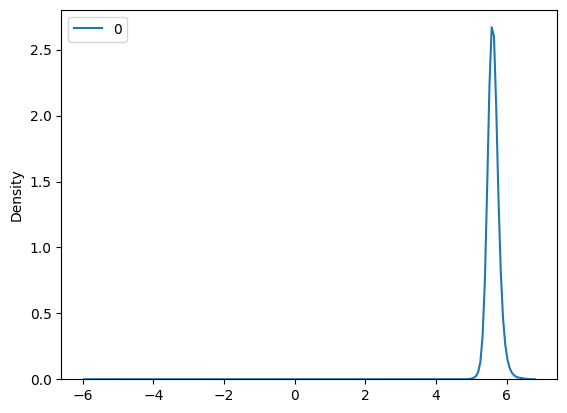

In [64]:
kdeplot(us_gen)

In [65]:
num_wd = wasserstein_1d(
    np.array(us_gen), samps, p=2
)
num_wd / base_wd

array([2.5385492])

<Axes: ylabel='Density'>

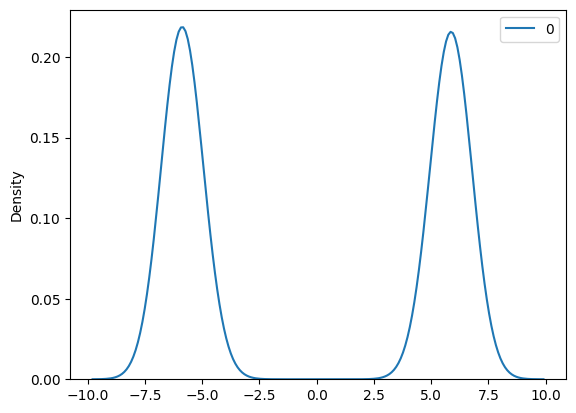

: 

In [ ]:
from seaborn import kdeplot
kdeplot(samps)